In [122]:
# GENERAL USE LIBRARY IMPORTS

import numpy as np, numpy.random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import calendar
from sklearn.linear_model import LinearRegression
import plotly.express as px
from IPython.display import Markdown as md
import random as rand
from matplotlib import gridspec
import yfinance as yf
from datetime import datetime
import getFamaFrenchFactors as gff
from pandas.tseries.offsets import DateOffset
from statsmodels.formula.api import ols
import statsmodels.api as sm
import random
yf.pdr_override()
import warnings

# To ignore all warnings
warnings.filterwarnings("ignore")

# OPTIMIZATION LIBRARY IMPORTS
import pulp
from pulp import *
from sklearn.preprocessing import LabelEncoder

In [664]:
#Getting SP_500 Tickers as a list
list_of_dfs = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
wikitable_sp_500 = list_of_dfs[0]
sp500_symbols = wikitable_sp_500['Symbol']

#Converting SP_500 tickers into list
tickers = sp500_symbols.to_list()

In [124]:
all_stocks = pd.read_excel('all_stocks.xlsx')
all_stocks = all_stocks['Symbol'].tolist()

In [125]:
random.seed(42)
tickers = random.sample(all_stocks,700)

In [126]:
russell_2000_tickers = pd.read_excel('russell_2000.xlsx')
russell2000_tickers = russell_2000_tickers['Ticker'].tolist()

In [665]:
#Getting SP_600 Tickers as a list
list_of_dfs = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_600_companies')
wikitable_sp_600 = list_of_dfs[0]
sp600_symbols = wikitable_sp_600['Symbol']

#Converting SP_500 tickers into list
sp600_tickers = sp600_symbols.to_list()

In [666]:
#Start Date for In Sample Historical Data
start = '2012-12-01'
#End Date for In Sample Historical Data
end   = '2018-01-01'
#Monthly Returns for Stocks in the List
monthly_data = yf.download(tickers,start=start,end=end,interval='1mo')
#Reformat Date Index
monthly_data.index = pd.to_datetime(monthly_data.index)
monthly_data = monthly_data.tz_localize(None)
#Turn Adj Close prices into pct returns
monthly_data = monthly_data['Adj Close'].pct_change()
#Drop First row NaN values
monthly_data = monthly_data.drop(monthly_data.index[0])
#Drop if stock doesnt have data starting from the first index date
monthly_data = monthly_data.dropna(axis=1)
#Assign equal weight as base weights
base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])
#Getting SP_500 data
spy = pd.DataFrame(yf.download('^GSPC',start=start,end=end,interval='1mo')['Adj Close'].pct_change())
#Dropping First Row(NaN) and formatting index to match monthly_data
spy = spy.drop(spy.index[0]).tz_localize(None)
#Adding SP_500 data to monthly_data
monthly_data['SP_500'] = spy['Adj Close']

[*                      3%%                      ]  17 of 503 completed

[*********************100%%**********************]  503 of 503 completed


19 Failed downloads:
['CARR', 'VICI', 'ABNB', 'GEHC', 'UBER', 'DAY', 'MRNA', 'FOXA', 'VLTO', 'DOW', 'GEV', 'OTIS', 'FOX', 'SOLV', 'CTVA', 'KVUE', 'CEG']: Exception("%ticker%: Data doesn't exist for startDate = 1354338000, endDate = 1514782800")
['BF.B']: Exception('%ticker%: No price data found, symbol may be delisted (1mo 2012-12-01 -> 2018-01-01)')
['BRK.B']: Exception('%ticker%: No timezone found, symbol may be delisted')



[*********************100%%**********************]  1 of 1 completed


In [667]:
#Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
tickers = list(monthly_data.columns[:-1])
tick_index = tickers + ['SP_500']

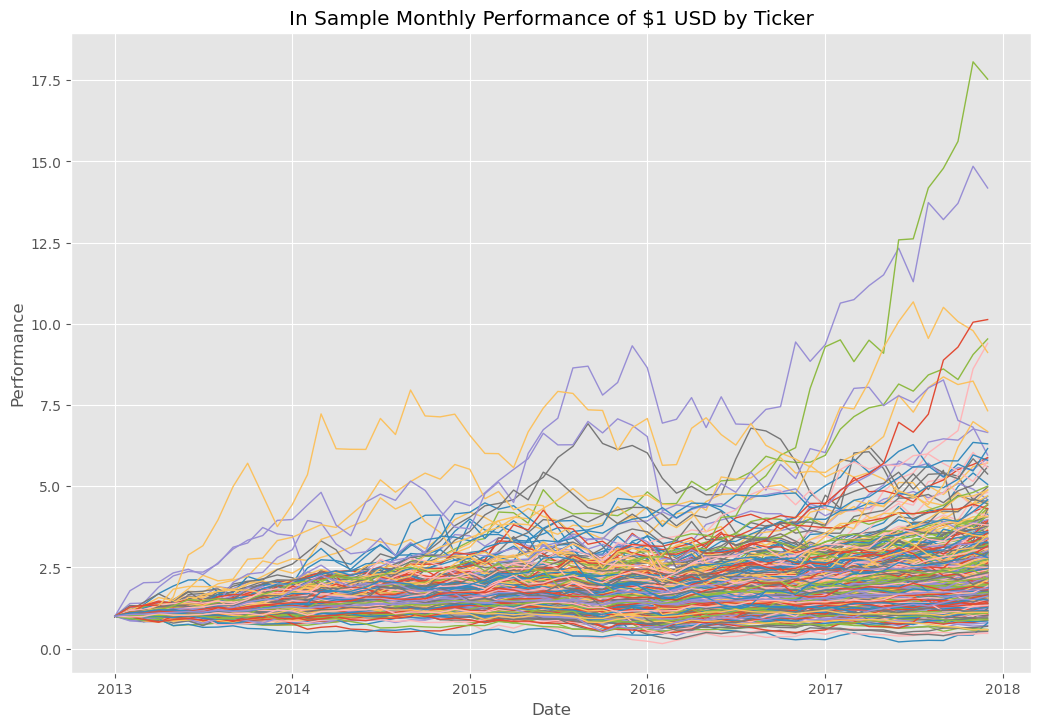

In [668]:
# IN SAMPLE HISTORICAL MONTHLY PERFORMANCE

init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)

performance = pd.DataFrame(np.ones((len(monthly_data),len(monthly_data.columns))), index = monthly_data.index, columns = monthly_data.columns)
for j in range(1,len(monthly_data.index)):
    performance.iloc[j] = performance.iloc[j-1]*(monthly_data.iloc[j-1][monthly_data.columns]+init)
plt.style.use('ggplot')
fig = plt.figure(figsize=(12,8), dpi=100)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)

# Plot on that set of axes
for i in range(0,len(monthly_data.columns)):
        axes.plot(performance.index, performance.iloc[:,i], linewidth=1)

#axes.set_prop_cycle(cycler)
axes.set_xlabel('Date')
axes.set_ylabel('Performance')
axes.set_title('In Sample Monthly Performance of $1 USD by Ticker')
#axes.legend(tick_index, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')

plt.show()

In [669]:
# Fama French Monthly Data using getFamaFrenchFactors module
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')

# Keeping Only the Dates in the monthly_data
ff3_monthly = ff3_monthly.loc[monthly_data.index]

In [670]:
# Statistical Info About Fama/French Factors
ff3_monthly.describe()

,Mkt-RF,SMB,HML,RF
count,60.000000,60.000000,60.000000,60.000000
mean,0.012655,-0.000343,-0.000240,0.000168
std,0.028530,0.023573,0.022994,0.000275
min,-0.060400,-0.044000,-0.041300,0.000000
25%,-0.000625,-0.018800,-0.015250,0.000000
50%,0.013250,0.003300,-0.002500,0.000000
75%,0.028875,0.013000,0.011750,0.000200
max,0.077500,0.057100,0.082100,0.000900


In [671]:
# Create an empty DataFrame to store the Stock Betas
stock_betas = pd.DataFrame()

# Iterate over the tickers list
for col in monthly_data.columns:
    # Set the dependent variable (Return of stock i)
    y = monthly_data[col]

    # Set the independent variables (Fama French 3 Factors)
    X = ff3_monthly[['Mkt-RF','SMB','HML']]

    # Fit the multiple linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Store the results in the DataFrame
    stock_betas[col] = [model.intercept_] + list(model.coef_)
stock_betas = stock_betas.T
stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

In [672]:
# Statistical Info about Factor Betas of Stocks
stock_betas.describe()

,Intercept,Mkt-RF,SMB,HML
count,458.000000,458.000000,458.000000,458.000000
mean,0.004170,0.967026,0.075095,-0.073768
std,0.008898,0.432351,0.454343,0.640750
min,-0.026795,-0.072626,-2.353883,-2.376518
25%,-0.001043,0.694638,-0.214453,-0.450242
50%,0.003816,0.970559,0.059217,-0.137653
75%,0.008395,1.237785,0.350868,0.244584
max,0.038314,2.607658,2.212082,2.306578


In [673]:
# Correlation of Factors
ff3_monthly.corr()

,Mkt-RF,SMB,HML,RF
Mkt-RF,1.000000,0.263912,0.048374,0.058675
SMB,0.263912,1.000000,0.183278,-0.041984
HML,0.048374,0.183278,1.000000,-0.034214
RF,0.058675,-0.041984,-0.034214,1.000000


In [674]:
#Stock Prices on the Day of Optimization (Rebalancing)
stock_price = pd.DataFrame(yf.download(tickers,start=start,end=end,interval='1d')['Adj Close'])
stock_price = stock_price[-1:]
stock_price.index = pd.to_datetime(stock_price.index).tz_localize(None)

s_price = {}
s_keys = list(tickers)
s_values =  list(stock_price.iloc[0])
for key,value in zip(s_keys,s_values):
    s_price[key] = value

[                       0%%                      ]  2 of 457 completed

[*********************100%%**********************]  457 of 457 completed


In [675]:
#Transaction Costs
random.seed(1)
t_cost = {}
keys       = list(tickers)
#values     = [.15 for i in range(len(keys))]
values = list(random.uniform(.01,.02) for i in range(len(tickers)))
for key,value in zip(keys,values):
    t_cost[key] = value

In [676]:
#SP_500 Factor Betas
stock_betas.iloc[-1,1:]

Mkt-RF    0.979146
SMB      -0.141978
HML      -0.012628
Name: SP_500, dtype: float64

In [677]:
# TARGET FACTOR BETAS
mkt_opt = 1.25                          # TARGET MKT BETA
smb_opt = 0.30                          # TARGET SMB BETA
hml_opt = 0.05                          # TARGET HML BETA
base_weights = base_w.T*0
B = 1000000                             # BUDGET

In [678]:
from openpyxl import Workbook
wb = Workbook()
ws = wb.active


In [679]:
#Save Target Betas in excel

ws['A1'] = 'Target Betas'
ws['A2'] = 'Mkt-RF'
ws['A3'] = 'SMB'
ws['A4'] = 'HML'
ws['B2'] = mkt_opt
ws['B3'] = smb_opt
ws['B4'] = hml_opt

#save wb

wb.save('results_test.xlsx')


In [680]:
# OPTIMIZATION MODEL

index = LpProblem('Index', LpMinimize)

# Decision Variables

wei = LpVariable.dicts('Weight',tickers,lowBound=0)                           # Weights for stock i in the optimal portfolio
aux = LpVariable.dicts('Y',tickers,lowBound=0)                                # Absolute value of change for stock i from base weights
err = LpVariable.dicts('Error', monthly_data.index, lowBound=0)               # Error term for portfolio
binary = LpVariable.dicts('bin',tickers,cat=LpBinary)                         # Used if we want to limit the # of stocks we want to have in optimal portfolio
tr_cost = LpVariable.dicts('Transaction_Cost',tickers,lowBound=0)             # Total Transaction cost for stock i in the optimal portfolio
shares = LpVariable.dicts('shares',tickers,lowBound=0)             

#Objective Function - Minimize the error term
index +=  lpSum(err[t] for t in monthly_data.index)

# Constraint: Weights sum to 1
index += lpSum(wei[i] for i in tickers) == 1

# Constraint: Absolute value of change in weights from base weigths
for i in tickers:
    index += aux[i] >= base_weights[i]  - wei[i]
    index += aux[i] >= wei[i] - base_weights[i]
index += lpSum(aux[i] for i in tickers) <= 1
# Constraint: Error term
for t in monthly_data.index:
    index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) - err[t] <= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
    index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) + err[t] >= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])

# Shares
for i in tickers:
    index += shares[i] == (aux[i]*B/s_price[i])

# Transaction Costs
for i in tickers:
    index += lpSum(aux[i] *B*t_cost[i]/s_price[i]) == tr_cost[i]
index += lpSum(tr_cost[i] for i in tickers) <= 2000
# Limit # of stocks in Optimal Portfolio
for i in tickers: # Forces weight of stock i to be less than binary value of stock i. If stock is not selected binary variable is 0 which then forces weight of stock i to be in the optimal portfolio to be 0.
    index += wei[i] <= binary[i]

index += lpSum(binary[i] for i in tickers) <= 100

index.solve()

1

In [681]:
#Change in number of shares
sharess = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 's'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 's'] , columns = ['Optimal'])
sharess.to_excel('shares.xlsx')

#Transaction Costs
tr_cost = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
tr_cost.sum()

#Optimal weights
weii = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'W'] , columns = ['Optimal'])
weii.sum()

#Change of weights
auxx = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
auxx.sum()

#Error terms
errr = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
errr.sum()

# Check if Binary Values Constraint works
binary_v = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
binary_v.sum()

# Weights in Optimal Portfolio
opt_weights = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
print("Transaction Costs:", tr_cost.sum().values[0].round(2))
print("Optimal Weights:", weii.sum().values[0].round(2))
print("Change of Weights:", auxx.sum().values[0].round(2))
print("Error Terms:", errr.sum().values[0].round(2))
print("Binary Constraint:", binary_v.sum().values[0].round(2))
opt_weights.style.format('{:,.2%}'.format)

Transaction Costs: 168.03
Optimal Weights: 1.0
Change of Weights: 1.0
Error Terms: 0.0
Binary Constraint: 62.0


,Optimal
Weight_ABT,1.78%
Weight_AME,0.82%
Weight_AMGN,0.58%
Weight_AMP,6.24%
Weight_AMZN,1.24%
Weight_AOS,3.63%
Weight_AZO,0.75%
Weight_CAT,3.57%
Weight_CBOE,0.11%
Weight_CCL,0.35%


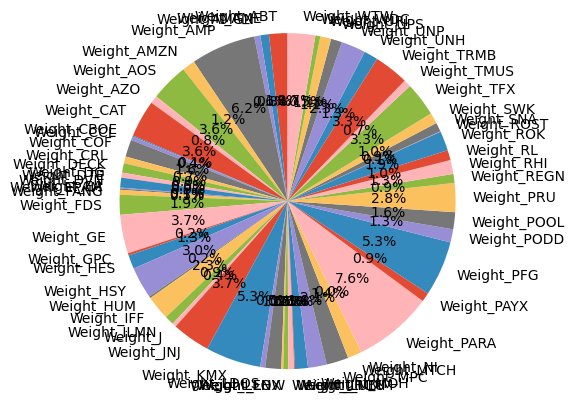

In [682]:
# Plot
fig, ax = plt.subplots()
ax.pie(opt_weights['Optimal'], labels=opt_weights.index, autopct='%1.1f%%', startangle=90)
ax.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.

plt.show()

In [683]:
fig.savefig('optimal_weights_pie_chart.png')

In [684]:
#save optimal weights pie chart in excel
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
wb = load_workbook('results_test.xlsx')
ws = wb.active
p0 = Image('optimal_weights_pie_chart.png')

ws.add_image(p0, 'G50')
wb.save('results_test.xlsx')


In [685]:
# WEIGHTS AND RETURNS OLD PORTFOLIO VS. NEW PORTFOLIO

weights_new = pd.DataFrame([v.varValue for v in index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
weights = pd.DataFrame(np.zeros((len(monthly_data.columns[:-1]),3)), index=monthly_data.columns[:-1], columns=['PORTFOLIO Weights','Difference','New Weights'])
for t in monthly_data.columns[:-1]:
    weights.loc[t][0] = base_w.loc[t]
    weights.loc[t][1] = weights_new.loc[t][0]-base_w.loc[t][0]
    weights.loc[t][2] = weights_new.loc[t]
weights

,PORTFOLIO Weights,Difference,New Weights
A,0.002188,-0.002188,0.000000
AAL,0.002188,-0.002188,0.000000
AAPL,0.002188,-0.002188,0.000000
ABT,0.002188,0.015576,0.017764
ACGL,0.002188,-0.002188,0.000000
...,...,...,...
XOM,0.002188,-0.002188,0.000000
XYL,0.002188,-0.002188,0.000000
YUM,0.002188,-0.002188,0.000000
ZBH,0.002188,-0.002188,0.000000


In [686]:
# CHECK PORTFOLIO BETAS

port_returns = pd.DataFrame(np.zeros((len(monthly_data.index),2)), index=monthly_data.index, columns=["SP_500","Optimization"])
for j in port_returns.index:
    port_returns.loc[j]["SP_500"] = monthly_data.loc[j]['SP_500']
    port_returns.loc[j]['Optimization'] = monthly_data.loc[j,:monthly_data.columns[-2]].dot(weights['New Weights'])
port_returns = port_returns.merge(ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)

# Create an empty DataFrame to store the Portfolio Beta
port_betas = pd.DataFrame(np.zeros((3,4)), index=ff3_monthly.columns[0:3], columns=["SP_500", "Target", "Optimization", "Abs. Diff"])

port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]

# Set the independent variables (Fama French 3 Factors)
X = port_returns[['Mkt-RF','SMB','HML']]
# Set the dependent variable (Return of Portfolio)
Y = port_returns['SP_500']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
port_betas['SP_500'] = regr.coef_

# Set the dependent variable (Return of Portfolio)
Y = port_returns['Optimization']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
port_betas['Optimization'] = regr.coef_

# Abs Difference between Target Betas & Optimal Portfolio Betas
port_betas["Abs. Diff"] = round(abs(port_betas['Optimization'] - port_betas["Target"]),4)
port_betas

,SP_500,Target,Optimization,Abs. Diff
Mkt-RF,0.979146,1.25,1.250723,0.0007
SMB,-0.141978,0.30,0.299337,0.0007
HML,-0.012628,0.05,0.049672,0.0003


In [687]:
sb = stock_betas[['SMB','HML']]

# Initialize the result DataFrame
stock_factor = pd.DataFrame(columns=['Ticker', 'Factor'])

# Iterate through elements in list1
for element in tickers:
    # Check if the element is in list2 and list3
    in_list2 = element in sp600_tickers
    in_list3 = element in russell2000_tickers
    
    # If element is in both list2 and list3, check scores
    if in_list2 and in_list3:
        list2_score = sb.loc[element, 'SMB']
        list3_score = sb.loc[element, 'HML']
        
        # Determine the list with the higher score
        if list2_score > list3_score:
            list_name = 'Size'
        elif list3_score > list2_score:
            list_name = 'Value'
        else:
            list_name = 'Equal'
    elif in_list2:
        list_name = 'Size'
    elif in_list3:
        list_name = 'Value'
    else:
        list_name = 'Market'
    
    # Append a row to the result DataFrame
    stock_factor = stock_factor.append({'Ticker': element, 'Factor': list_name}, ignore_index=True)

stock_factor = stock_factor.set_index('Ticker')

# Specify the columns to remove
columns_to_remove = ['PORTFOLIO Weights', 'Difference']

# Specify the column to filter non-zero values
column_to_filter = 'New Weights'

# Create a new DataFrame with selected columns and rows where New Weights is not equal to 0
opt_portf_weights = weights.drop(columns=columns_to_remove)[weights[column_to_filter] != 0]

opt_portf_weights.to_excel('opt_portf_weights.xlsx')

# Add Factor Column for the stocks in the Optimal Portfolio
opt_portf_weights['Factor'] = opt_portf_weights.index.map(stock_factor['Factor'])

# Group Weights by Factors
size_factor_weight = opt_portf_weights[opt_portf_weights['Factor'] == 'Size']['New Weights'].sum()
value_factor_weight = opt_portf_weights[opt_portf_weights['Factor'] == 'Value']['New Weights'].sum()

In [688]:
# OUT OF SAMPLE HISTORICAL(OOS) DAILY DATA (**After Optimization**)
o1_start_d = '2017-12-01'
o1_end_d   = '2020-01-01'
# OOS 1 DAILY Returns for Stocks in the List
oos1_daily_data = yf.download(opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d,interval='1mo')
# Turn Adj Close prices into pct returns
oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
#Reformat Date Index
oos1_daily_data = oos1_daily_data.tz_localize(None)
#Adding SP_500 data
oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
oos1_daily_data['SP_500'] = oos1_spy_d['Adj Close']
#Create a Column of Returns for Optimal Portfolio Returns
oos1_daily_data['Optimized Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Optimal Portfolio Returns
for i in range(len(oos1_daily_data.index)):
    oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
oos1_daily_data

[*********************100%%**********************]  63 of 63 completed
[*********************100%%**********************]  1 of 1 completed


,ABT,AME,AMGN,AMP,AMZN,AOS,AZO,CAT,CBOE,CCL,...,TMUS,TRMB,UNH,UNP,UPS,URI,WDC,WTW,SP_500,Optimized Portfolio
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.089188,0.054171,0.069868,-0.004543,0.240639,0.089752,0.076008,0.032999,0.078658,0.078951,...,0.025035,0.085138,0.074027,-0.004474,0.068569,0.053516,0.125776,0.064901,0.056179,0.037078
2018-02-01,-0.024799,-0.007340,-0.012255,-0.072673,0.042429,-0.036188,-0.131584,-0.045659,-0.166531,-0.065633,...,-0.068971,-0.139909,-0.044852,-0.024344,-0.179940,-0.033239,-0.021803,-0.016016,-0.038947,-0.06963
2018-03-01,-0.006796,0.003037,-0.065306,-0.049420,-0.043049,-0.009347,-0.024115,-0.046886,0.021120,-0.013497,...,0.007095,-0.054047,-0.053767,0.037549,0.010888,-0.013479,0.060087,-0.036162,-0.026884,-0.003489
2018-04-01,-0.029873,-0.079568,0.023463,-0.052251,0.082075,-0.035226,-0.037260,-0.020492,-0.061867,-0.038426,...,-0.008683,-0.035675,0.108331,-0.005951,0.084464,-0.131593,-0.141436,-0.024180,0.002719,-0.012536
2018-05-01,0.063584,0.046275,0.029459,-0.011269,0.040539,0.030998,0.039710,0.057598,-0.083848,-0.012369,...,-0.079491,-0.044509,0.021616,0.068323,0.023084,0.063800,0.059906,0.017777,0.021608,0.016217
2018-06-01,-0.008776,-0.011913,0.035601,0.015971,0.043065,-0.062153,0.033281,-0.106905,0.069671,-0.072632,...,0.072711,-0.006655,0.015858,-0.002510,-0.077974,-0.074889,-0.073045,0.002977,0.004842,0.007027
2018-07-01,0.074602,0.080167,0.064792,0.041393,0.045676,0.006424,0.051570,0.059925,-0.066686,0.033677,...,0.004184,0.074909,0.035770,0.057948,0.128589,0.007994,-0.087887,0.051583,0.036022,0.04433
2018-08-01,0.024419,-0.010797,0.016586,-0.025468,0.132364,-0.021378,0.086956,-0.028502,0.040987,0.037981,...,0.100667,0.192635,0.060185,0.004870,0.024939,0.047513,-0.098503,-0.076214,0.030263,0.023705
2018-09-01,0.097547,0.028066,0.044496,0.046871,-0.004824,-0.081095,0.011501,0.098236,-0.045060,0.045529,...,0.062689,0.032304,-0.009015,0.086830,-0.042693,0.049593,-0.074320,-0.042982,0.004294,0.020626


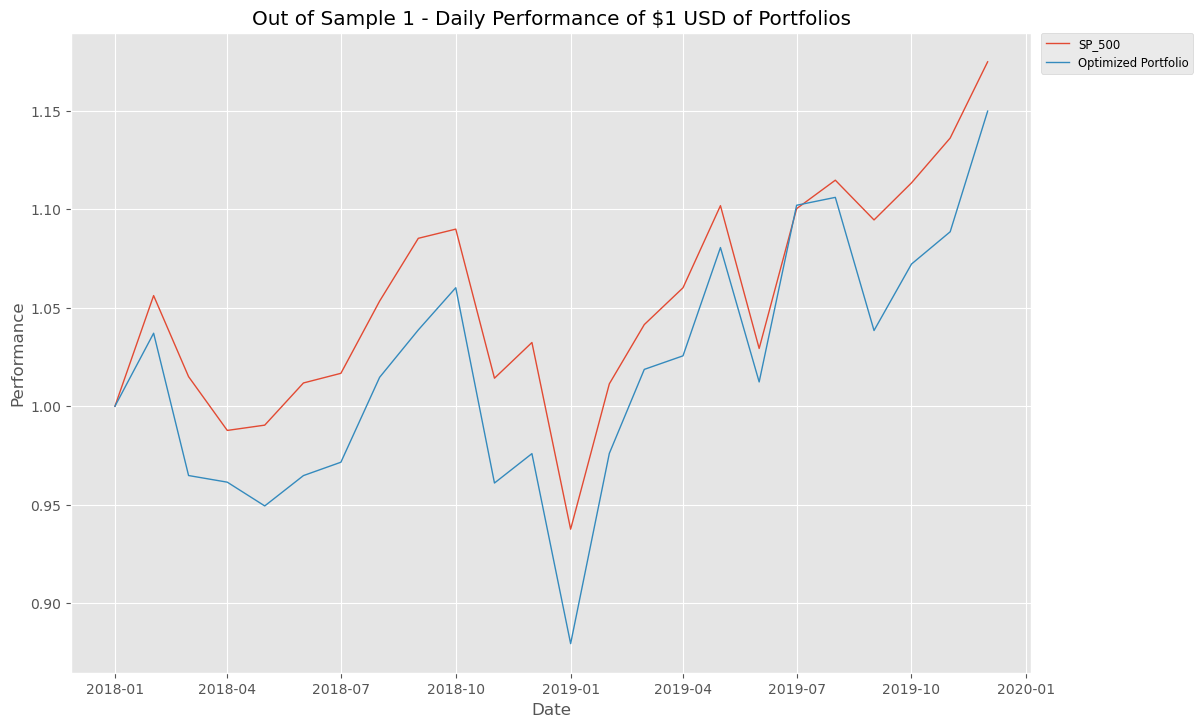

In [689]:
# OUT OF SAMPLE HISTORICAL(OOS) PERFORMANCE

init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)

oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
for j in range(1,len(oos1_daily_data.index)):
    oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
for j in range(1,len(oos1_daily_data.index)):
    oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
plt.style.use('ggplot')
fig = plt.figure(figsize=(12,8), dpi=100)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)

# Plot on that set of axes
for i in range(0,len(oos1_daily_data.columns[-2:])):
        axes.plot(oos1_new_performance.index, oos1_new_performance.iloc[:,i], linewidth=1)

#axes.set_prop_cycle(cycler)
axes.set_xlabel('Date')
axes.set_ylabel('Performance')
axes.set_title('Out of Sample 1 - Daily Performance of $1 USD of Portfolios')
axes.legend(oos1_daily_data.columns[-2:], bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')

plt.savefig('oos1_daily_performance.png')
plt.show()


In [690]:
oos1_new_performance

,SP_500,Optimized Portfolio
Date,,
2018-01-01,1.000000,1.000000
2018-02-01,1.056179,1.037078
2018-03-01,1.015043,0.964866
2018-04-01,0.987754,0.961500
2018-05-01,0.990440,0.949446
2018-06-01,1.011842,0.964843
2018-07-01,1.016741,0.971623
2018-08-01,1.053366,1.014695
2018-09-01,1.085244,1.038749


In [691]:
#Save the plt in excel
from openpyxl import load_workbook
import openpyxl as openpyxl
wb = load_workbook('results_test.xlsx')
ws = wb.active

p1 = openpyxl.drawing.image.Image('oos1_daily_performance.png')
ws.add_image(p1, 'G1')

wb.save('results_test.xlsx')


In [692]:
def hedge_portfolio_beta(current_beta, target_beta, hedge_ratio, contrat_size, size_of_position, factor_weight, index_futures_price, hedge_period, index_multiple):
    

    if target_beta > current_beta:
        # If target beta is greater, take a long position
        number_of_contracts = (target_beta - current_beta) * (hedge_ratio * (factor_weight * size_of_position) / contrat_size)
        hedge_profit = number_of_contracts * (index_futures_price['Adj Close'].iloc[index_futures_price.index.get_loc(o1_start_d) + hedge_period + 1] - index_futures_price['Adj Close'].iloc[index_futures_price.index.get_loc(o1_start_d) + 1])
        opt_portf_profit = B * (oos1_new_performance.loc[str(index_futures_price.index[index_futures_price.index.get_loc(o1_start_d)+ hedge_period + 1]),'Optimized Portfolio'] - oos1_new_performance.loc[str(index_futures_price.index[index_futures_price.index.get_loc(o1_start_d)+1]),'Optimized Portfolio'])
        total_profit = opt_portf_profit + hedge_profit
        action = "LONG"
    elif target_beta < current_beta:
        # If target beta is smaller, take a short position
        number_of_contracts = (current_beta - target_beta) * (hedge_ratio * size_of_position / contrat_size)
        hedge_profit = number_of_contracts * (index_futures_price['Adj Close'].iloc[index_futures_price.index.get_loc(o1_start_d) + 1] - index_futures_price['Adj Close'].iloc[index_futures_price.index.get_loc(o1_start_d) + hedge_period + 1]) * index_multiple
        opt_portf_profit = B * (oos1_new_performance.loc[str(index_futures_price.index[index_futures_price.index.get_loc(o1_start_d)+ hedge_period + 1]),'Optimized Portfolio'] - oos1_new_performance.loc[str(index_futures_price.index[index_futures_price.index.get_loc(o1_start_d)+1]),'Optimized Portfolio'])
        total_profit = opt_portf_profit + hedge_profit
        action = "SHORT"
    else:
        # If target beta is equal to current beta, no action needed
        action = "no action"
        number_of_contracts = 0
        total_profit = 0

    return action, number_of_contracts, hedge_profit, opt_portf_profit, total_profit, hedge_period


In [701]:
# MARKET FACTOR - SP_500 FUTURES MINIMUM VARIANCE HEDGE RATIO
sp500_futures = yf.download("ES=F",start=start,end=o1_end_d,interval='1mo')['Adj Close'].pct_change().dropna()
# Fama French Monthly Data using getFamaFrenchFactors module
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
ff3_monthly = ff3_monthly.loc[sp500_futures[:o1_start_d].index]
# Regression Analysis on Market Factor Vs SP 500 Futures Data 
y = ff3_monthly['Mkt-RF']
X = sp500_futures[:o1_start_d].values.reshape(-1,1)

mkt_model = LinearRegression()
mkt_model.fit(X, y)
market_hedge_ratio = mkt_model.coef_[0]
print('Minimum variance Hedge ratio for Mkt-RF Factor: {:,.2f}'.format(market_hedge_ratio))

# Futures Contract Price for Contract Multiplier
sp500_index_futures_price = yf.download("ES=F",interval='1mo')
sp500_index_futures_price.index = pd.to_datetime(sp500_index_futures_price.index)
sp500_index_futures_price = sp500_index_futures_price.tz_localize(None)
index_multiple = 50

# B is the size of the position
size_of_market_futures_contract = index_multiple * sp500_index_futures_price['Adj Close'].iloc[sp500_index_futures_price.index.get_loc(o1_start_d) + 1]


# mkt_opt is the current beta of Market Factor
mkt_target_beta = 0

# Hedging the Portfolio Using Index Futures
action, number_of_contracts, hedge_profit, opt_portf_profit, total_profit, hedge_period = hedge_portfolio_beta(mkt_opt,mkt_target_beta,market_hedge_ratio, size_of_market_futures_contract, B, 1, sp500_index_futures_price, 4, index_multiple)

print("To change beta from {} to {}, {} {:.0f} contracts over the next {} months and gain/loss from {} futures position is ${:,.2f}\nGain/Loss from optimal portfolio is ${:,.2f}\nTotal Gain/Loss from all of our positions is ${:,.2f}.".format(mkt_opt, mkt_target_beta, action, number_of_contracts, hedge_period, action, hedge_profit, opt_portf_profit, total_profit))


[*********************100%%**********************]  1 of 1 completed


Minimum variance Hedge ratio for Mkt-RF Factor: 0.91
[*********************100%%**********************]  1 of 1 completed
To change beta from 1.25 to 0, SHORT 8 contracts over the next 4 months and gain/loss from SHORT futures position is $42,033.99
Gain/Loss from optimal portfolio is $-35,156.78
Total Gain/Loss from all of our positions is $6,877.21.


#save the S_P 500 hedge results in excel

#add title
ws['A6'] = 'S_P 500 Hedge Results'

ws['A7']= 'Minimum Variance Hedge Ratio'
ws['B7'] = market_hedge_ratio

ws['A8'] = 'action'
ws['B8'] = action

ws['A9'] = 'Number of Contracts'
ws['B9'] = number_of_contracts

ws['A10'] = 'Total Profit/Loss'
ws['B10'] = total_profit


#save wb
wb.save('results_test.xlsx')



# SIZE FACTOR - E-mini Russell 2000 Index Future MINIMUM VARIANCE HEDGE RATIO
russell2000_futures = yf.download("RTY=F",start=start,end=o1_end_d,interval='1mo')['Adj Close'].pct_change().dropna()
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
ff3_monthly = ff3_monthly.loc[russell2000_futures[:o1_start_d].index]

# Regression Analysis on Size Factor Vs E-mini Russell 2000 Index Futures Data 
y = ff3_monthly['SMB']
X = russell2000_futures[:o1_start_d].values.reshape(-1,1)

smb_model = LinearRegression()
smb_model.fit(X, y)
size_hedge_ratio = smb_model.coef_[0]
print('Minimum variance Hedge ratio for Size Factor:',size_hedge_ratio)

# Futures Contract Price for Contract Multiplier
russell2000_index_multiples = yf.download("ES=F",interval='1mo')
russell2000_index_multiples.index = pd.to_datetime(russell2000_index_multiples.index)
russell2000_index_multiples = russell2000_index_multiples.tz_localize(None)
russell2000_index_multiple = russell2000_index_multiples['Adj Close'].loc[o1_start_d]

# B is the size of the position
size_of_smb_futures_contract = 50 * russell2000_index_multiple

# smb_opt is the current beta of Size Factor
smb_target_beta = .5

# Hedging the Portfolio Using Index Futures
action, number_of_contracts, total_profit = hedge_portfolio_beta(smb_opt,smb_target_beta, size_of_smb_futures_contract, B, size_factor_weight, russell2000_index_multiples,size_hedge_ratio)

print(f"To change beta from {smb_opt} to {smb_target_beta}, {action} {number_of_contracts:.2f} contracts and total profit/loss is ${total_profit:.2f}.")

#save the Russell 2000 hedge results in excel

#add title
ws['A12'] = 'Russell 2000 Hedge Results'

ws['A13']= 'Minimum Variance Hedge Ratio'
ws['B13'] = size_hedge_ratio

ws['A14'] = 'action'
ws['B14'] = action

ws['A15'] = 'Number of Contracts'
ws['B15'] = number_of_contracts

ws['A16'] = 'Total Profit/Loss'
ws['B16'] = total_profit


#save wb
wb.save('results_test.xlsx')

# VALUE FACTOR - E-mini Russell 1000 Value Index Future MINIMUM VARIANCE HEDGE RATIO
russell1000_futures = yf.download("RSV=F",start=start,end=o1_end_d,interval='1mo')['Adj Close'].pct_change().dropna()
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
ff3_monthly = ff3_monthly.loc[russell1000_futures[:o1_start_d].index]

# Regression Analysis on Value Factor Vs E-mini Russell 1000 Index Futures Data 
y = ff3_monthly['HML']
X = russell1000_futures[:o1_start_d].values.reshape(-1,1)

hml_model = LinearRegression()
hml_model.fit(X, y)
value_hedge_ratio = hml_model.coef_[0]
print('Minimum variance Hedge ratio for Value Factor:',value_hedge_ratio )

# Futures Contract Price for Contract Multiplier
russell1000_index_multiples = yf.download("ES=F",interval='1mo')
russell1000_index_multiples.index = pd.to_datetime(russell1000_index_multiples.index)
russell1000_index_multiples = russell1000_index_multiples.tz_localize(None)
russell1000_index_multiple = russell1000_index_multiples['Adj Close'].loc[o1_start_d]

# B is the size of the position
size_of_value_futures_contract = 50 * russell1000_index_multiple

# hml_opt is the current beta of Value Factor
hml_target_beta = 1.5

# Hedging the Portfolio Using Index Futures
action, number_of_contracts, total_profit = hedge_portfolio_beta(hml_opt,hml_target_beta, size_of_value_futures_contract, B, value_factor_weight, russell1000_index_multiples,value_hedge_ratio)

print(f"To change beta from {hml_opt} to {hml_target_beta}, {action} {number_of_contracts:.2f} contracts and total profit/loss is ${total_profit:.2f}.")

#save the Russell 1000 hedge results in excel

#add title
ws['A18'] = 'Russell 1000 Hedge Results'

ws['A19']= 'Minimum Variance Hedge Ratio'
ws['B19'] = value_hedge_ratio

ws['A20'] = 'action'
ws['B20'] = action

ws['A21'] = 'Number of Contracts'
ws['B21'] = number_of_contracts

ws['A22'] = 'Total Profit/Loss'
ws['B22'] = total_profit


#save wb
wb.save('results_test.xlsx')